# EDA - Smart Logistics Delay Prediction

**Name:** Sachin Kirtibhai Patel  
**UID:** U01124876  

This notebook is for basic exploratory data analysis of the Supply Chain dataset.  
The main goal is to understand the data before building models for late delivery prediction.

The cleaned file used here is:

`data/dataco_cleaned.csv`

Run preprocessing first if the cleaned file is not already created:

`python src/preprocessing.py`

In [ ]:
# libraries for EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette('Set2')

%matplotlib inline

In [ ]:
# load cleaned data
df = pd.read_csv('../data/dataco_cleaned.csv')

print("Data loaded")
print("Shape :- ", df.shape)
print("Number of columns :- ", len(df.columns))

df.head()

Data loaded
Shape :-  (50000, 28)
Number of columns :-  28


,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Name,Customer Segment,Department Name,Latitude,Longitude,...,Order Profit Per Order,Order Region,Product Price,Shipping Mode,ord_hour,ord_day,ord_month,ord_year,weekend_flag,ship_gap
0,TRANSFER,1,90.989998,349.959992,1,Children's Clothing,Corporate,Apparel,18.209276,-66.037056,...,90.989998,Western Europe,357.100006,First Class,19,0,10,2017,0,2
1,DEBIT,2,7.860000,124.790001,1,Men's Footwear,Corporate,Apparel,27.965654,-82.252808,...,7.860000,Southern Europe,129.990005,Second Class,8,5,7,2017,1,6
2,DEBIT,4,54.790001,188.919998,0,Indoor/Outdoor Games,Consumer,Fan Shop,36.738895,-119.787903,...,54.790001,West of USA,49.980000,Standard Class,1,4,4,2016,0,2
3,CASH,1,14.870000,43.980000,1,Indoor/Outdoor Games,Corporate,Fan Shop,33.905682,-118.160255,...,14.870000,West of USA,49.980000,First Class,11,3,6,2016,0,2
4,TRANSFER,2,-29.820000,127.970001,1,Shop By Sport,Consumer,Golf,34.014198,-117.854736,...,-29.820000,Central America,39.990002,Second Class,19,4,1,2015,0,3


## 1. Dataset and Target Variable

First I checked the dataset size, missing values, duplicates, and the target column.

In [ ]:
# basic information about the dataset

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (50000, 28)

Data types:
Type                                 str
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Late_delivery_risk                 int64
Category Name                        str
Customer Segment                     str
Department Name                      str
Latitude                         float64
Longitude                        float64
Market                               str
Order Item Discount              float64
Order Item Discount Rate         float64
Order Item Product Price         float64
Order Item Profit Ratio          float64
Order Item Quantity                int64
Sales                            float64
Order Item Total                 float64
Order Profit Per Order           float64
Order Region                         str
Product Price                    float64
Shipping Mode                        str
ord_hour                           int64
ord_day                  

In [ ]:
# target distribution

target_count = df['Late_delivery_risk'].value_counts()
target_percent = df['Late_delivery_risk'].value_counts(normalize=True) * 100

print("Target distribution")
print("On-time:- ", target_count[0], "(", round(target_percent[0],1), "% )")
print("Late:- ", target_count[1], "(", round(target_percent[1],1), "% )")

baseline_acc = max(target_percent[0], target_percent[1])
print("\nBaseline accuracy:- ", round(baseline_acc,1), "%")

Target distribution
On-time:-  22585 ( 45.2 % )
Late:-  27415 ( 54.8 % )

Baseline accuracy:-  54.8 %


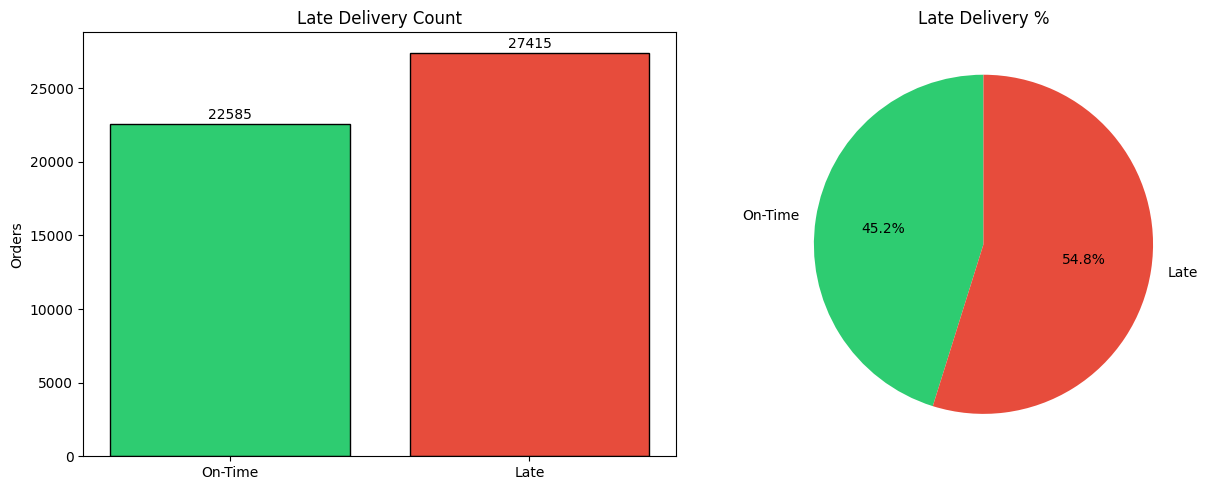

In [ ]:
# target distribution plot

fig, axes = plt.subplots(1,2, figsize=(13,5))

colors = ['#2ecc71','#e74c3c']
labels = ['On-Time','Late']

counts = df['Late_delivery_risk'].value_counts().sort_index()

# bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Late Delivery Count')
axes[0].set_ylabel('Orders')

for i,v in enumerate(counts.values):
    axes[0].text(i, v+300, str(v), ha='center')

# pie chart
axes[1].pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[1].set_title('Late Delivery %')

plt.tight_layout()

plt.savefig('../results/plots/01_target_distribution.png',
            dpi=100,
            bbox_inches='tight')

plt.show()

## 2. Shipping Mode Analysis

Here I looked at whether shipping mode has a relationship with late deliveries.

Late delivery by shipping mode
First Class: 95.5% late (7690 orders)
Same Day: 45.6% late (2640 orders)
Second Class: 76.9% late (9814 orders)
Standard Class: 37.9% late (29856 orders)


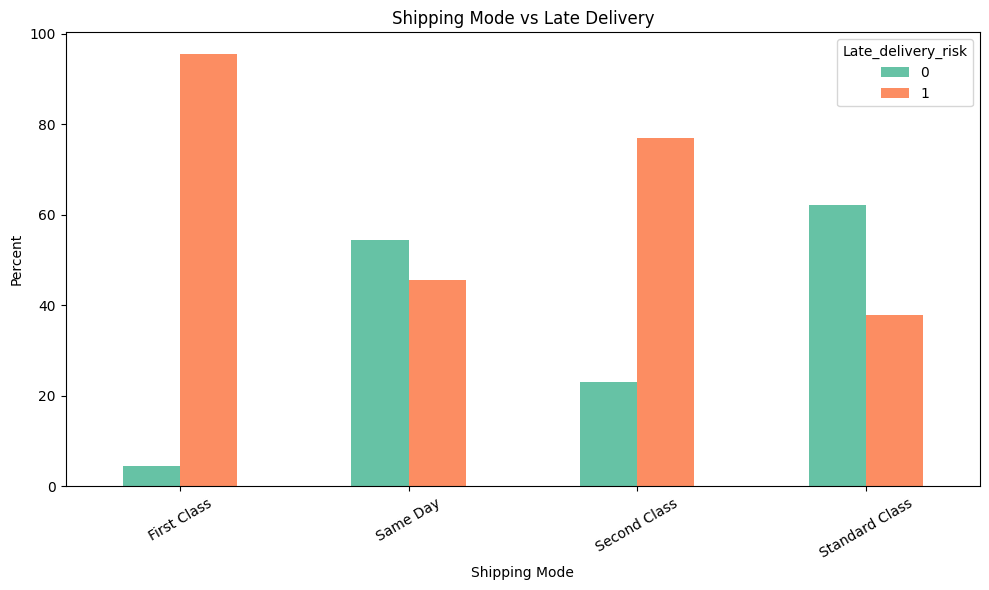

In [ ]:
# shipping mode vs late delivery

ship_delay = pd.crosstab(
    df['Shipping Mode'],
    df['Late_delivery_risk'],
    normalize='index'
) * 100

ship_count = df['Shipping Mode'].value_counts()

print("Late delivery by shipping mode")

for mode in ship_delay.index:
    late_pct = round(ship_delay.loc[mode,1],1)
    orders = ship_count[mode]

    print(f"{mode}: {late_pct}% late ({orders} orders)")


ship_delay.plot(kind='bar', figsize=(10,6))

plt.title('Shipping Mode vs Late Delivery')
plt.ylabel('Percent')
plt.xlabel('Shipping Mode')
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig('../results/plots/02_shipping_mode_delay.png',
            dpi=100,
            bbox_inches='tight')

plt.show()

## 3. Processing Days Analysis

Here I checked whether longer processing time is related to late deliveries.

Late delivery rate by processing days
0 days: 45.6 % late ( 2640 orders )
2 days: 46.6 % late ( 15769 orders )
3 days: 24.2 % late ( 7992 orders )
4 days: 24.0 % late ( 7892 orders )
5 days: 95.7 % late ( 7775 orders )
6 days: 95.8 % late ( 7932 orders )


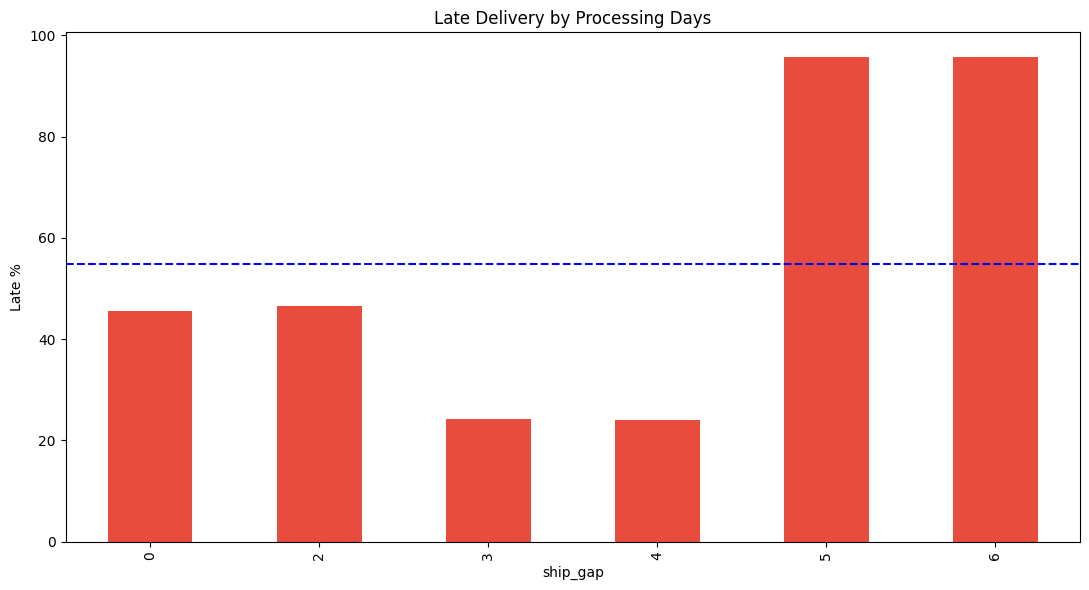

In [ ]:
# late delivery rate by processing days

print("Late delivery rate by processing days")

proc_stats = df.groupby('ship_gap')['Late_delivery_risk'].agg(['mean','count'])

proc_stats['late_pct'] = (proc_stats['mean'] * 100).round(1)

for days in sorted(proc_stats.index):
    pct = proc_stats.loc[days,'late_pct']
    cnt = proc_stats.loc[days,'count']

    print(days, "days:", pct, "% late (", cnt, "orders )")


# plot
fig, ax = plt.subplots(figsize=(11,6))

late_rates = df.groupby('ship_gap')['Late_delivery_risk'].mean() * 100

late_rates.plot(
    kind='bar',
    ax=ax,
    color='#e74c3c'
)

ax.axhline(
    y=54.8,
    color='blue',
    linestyle='--',
    label='Avg late rate'
)

ax.set_title('Late Delivery by Processing Days')
ax.set_ylabel('Late %')

plt.tight_layout()

plt.savefig('../results/plots/03_processing_days.png',
            dpi=100,
            bbox_inches='tight')

plt.show()

## 4. Correlation Analysis

Here I checked which numerical features have higher correlation with late delivery.

Top correlated features
ship_standard : -0.4142
ship_gap : 0.3786
Days for shipment (scheduled) : -0.3739
ship_first : 0.3486
ship_second : 0.2194
ord_hour : 0.0451
ship_sameday : -0.0436
ord_month : 0.008
ord_year : -0.0079
ord_day : 0.0049
Longitude : 0.0048
Order Item Quantity : -0.0043
weekend_flag : 0.0034
Benefit per order : -0.0025
Order Profit Per Order : -0.0025


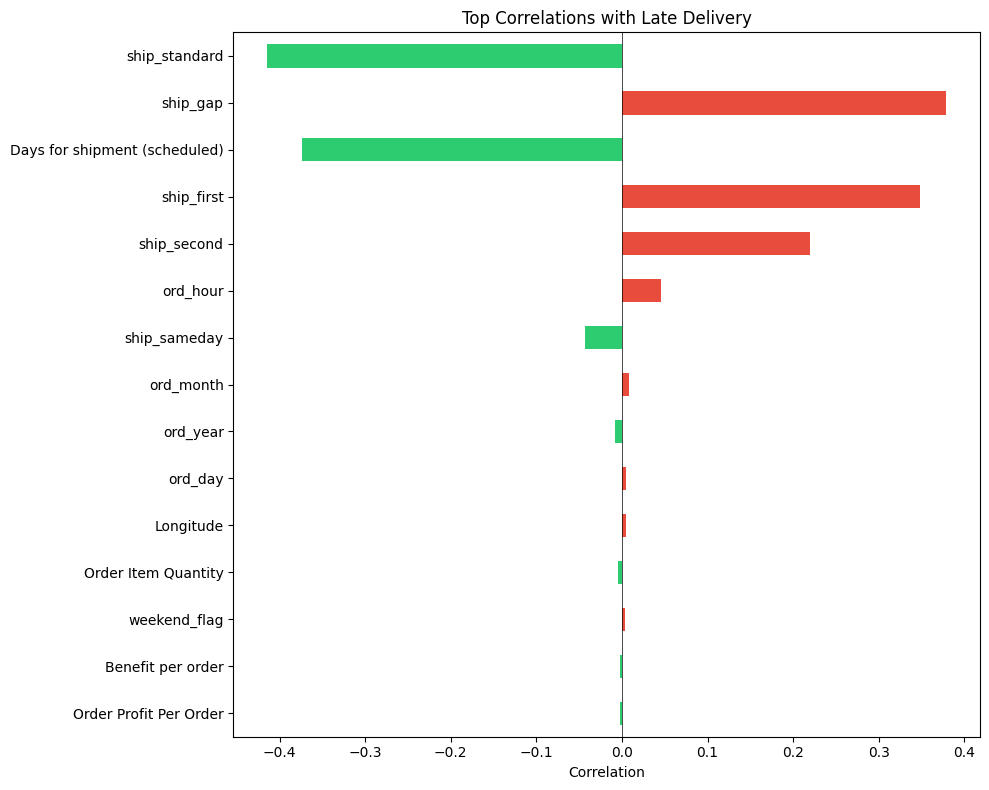

In [ ]:
# correlation analysis

df_corr = df.copy()

df_corr['ship_first'] = (df_corr['Shipping Mode'] == 'First Class').astype(int)
df_corr['ship_second'] = (df_corr['Shipping Mode'] == 'Second Class').astype(int)
df_corr['ship_standard'] = (df_corr['Shipping Mode'] == 'Standard Class').astype(int)
df_corr['ship_sameday'] = (df_corr['Shipping Mode'] == 'Same Day').astype(int)

num_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Late_delivery_risk')

corr_vals = df_corr[num_cols + ['Late_delivery_risk']].corr()['Late_delivery_risk']
corr_vals = corr_vals.drop('Late_delivery_risk')
corr_vals = corr_vals.sort_values(key=abs, ascending=False)

print("Top correlated features")
for col, val in corr_vals.head(15).items():
    print(col, ":", round(val,4))


# plot
fig, ax = plt.subplots(figsize=(10,8))

top_corr = corr_vals.head(15)

colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_corr.values]

top_corr.plot(kind='barh',
              ax=ax,
              color=colors_bar)

ax.set_title('Top Correlations with Late Delivery')
ax.set_xlabel('Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()

plt.tight_layout()

plt.savefig('../results/plots/04_correlations.png',
            dpi=100,
            bbox_inches='tight')

plt.show()

## EDA Summary

Some patterns from the analysis:

- About 54.8% of orders are late.
- Shipping mode seems related to delay risk.
- Orders with larger ship_gap show higher late delivery rates.
- Some features appear more useful for prediction than others.

These results helped decide which features to use in modeling.